# Filtro de Kalman: Estimando a Altura de um Prédio

Este notebook demonstra a aplicação do **filtro de Kalman escalar** (sem modelo dinâmico)
para estimar a altura real de um prédio a partir de medições ruidosas de um sensor.

## Contexto do problema

- Temos **10 medições** da altura de um prédio, todas com ruído.
- A altura do prédio é **constante** (não muda ao longo do tempo).
- O objetivo é estimar a **altura real** filtrando o ruído das medições.

Esse é o caso mais simples de filtro de Kalman: o estado é constante, não há modelo de transição.

## Modelo do Filtro de Kalman Escalar

Como o estado (altura) é constante, o modelo de transição é a identidade:

$$x_k = x_{k-1} + w_k, \quad w_k \sim \mathcal{N}(0, Q)$$

A medição é:

$$z_k = x_k + v_k, \quad v_k \sim \mathcal{N}(0, R)$$

### Equações do filtro

**Predição:**

$$\hat{x}_{k|k-1} = \hat{x}_{k-1|k-1}$$

$$P_{k|k-1} = P_{k-1|k-1} + Q$$

**Correção:**

$$K_k = \frac{P_{k|k-1}}{P_{k|k-1} + R}$$

$$\hat{x}_{k|k} = \hat{x}_{k|k-1} + K_k \cdot (z_k - \hat{x}_{k|k-1})$$

$$P_{k|k} = (1 - K_k) \cdot P_{k|k-1}$$

Onde:
- $K_k$ é o **ganho de Kalman** (quanto confiar na medição vs. na estimativa)
- $P_k$ é a **variância do erro** da estimativa
- $R$ é a **variância do ruído** de medição
- $Q$ é a **variância do ruído** do processo (0 aqui, pois o estado é constante)

## 1. Imports

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## 2. Carregamento dos dados

In [ ]:
RAIZ = Path().resolve().parent.parent
CAMINHO = RAIZ / "arquivos" / "exemplo5_predio.csv"

df = pd.read_csv(CAMINHO)
df

,n,medicao_m
0,1,49.03
1,2,48.44
2,3,55.21
3,4,49.98
4,5,50.60
5,6,52.61
6,7,45.87
7,8,42.64
8,9,48.26
9,10,55.84


: 

## 3. Parâmetros do filtro

| Parâmetro | Valor | Significado |
|-----------|-------|-------------|
| $x_0$ | 60.0 m | Estimativa inicial da altura |
| $P_0$ | 225.0 m² | Variância inicial do erro ($\sigma_0 = 15$ m) |
| $R$ | 25.0 m² | Variância do ruído de medição ($\sigma_R = 5$ m) |
| $Q$ | 0 m² | Variância do ruído do processo (estado constante) |

In [3]:
# Estado inicial
x = 60.0     # estimativa da altura (m)
p = 225.0    # variância do erro da estimativa (m²)
r = 25.0     # variância do ruído de medição (m²)

# Para o primeiro passo, predição = estado atual
x_pred = x
p_pred = p

## 4. Execução do filtro

Para cada medição $z_k$:
1. Calcula o **ganho de Kalman** $K$
2. **Corrige** o estado e a covariância
3. Usa o estado corrigido como previsão para o próximo passo

In [4]:
ganhos = []
estimativas = []
variancias = []

for z in df["medicao_m"]:
    # Ganho de Kalman: peso relativo entre medição e estimativa
    K = p_pred / (p_pred + r)

    # Correção do estado
    x = x_pred + K * (z - x_pred)

    # Correção da covariância
    p = (1 - K) * p_pred

    ganhos.append(K)
    estimativas.append(x)
    variancias.append(p)

    # Predição para o próximo passo (estado constante)
    x_pred = x
    p_pred = p

ganhos = np.array(ganhos)
estimativas = np.array(estimativas)
variancias = np.array(variancias)
medicoes = df["medicao_m"].to_numpy()
n_passos = np.arange(1, len(medicoes) + 1)

print(f"{'Passo':>5} | {'Medido (m)':>10} | {'Estimado (m)':>12} | {'Erro (m)':>8} | {'Ganho K':>8}")
print("-" * 55)
for i in range(len(medicoes)):
    erro = medicoes[i] - estimativas[i]
    print(f"{n_passos[i]:5d} | {medicoes[i]:10.2f} | {estimativas[i]:12.4f} | {erro:8.4f} | {ganhos[i]:8.4f}")

Passo | Medido (m) | Estimado (m) | Erro (m) |  Ganho K
-------------------------------------------------------
    1 |      49.03 |      50.1270 |  -1.0970 |   0.9000
    2 |      48.44 |      49.3279 |  -0.8879 |   0.4737
    3 |      55.21 |      51.2186 |   3.9914 |   0.3214
    4 |      49.98 |      50.9173 |  -0.9373 |   0.2432
    5 |      50.60 |      50.8552 |  -0.2552 |   0.1957
    6 |      52.61 |      51.1424 |   1.4676 |   0.1636
    7 |      45.87 |      50.4009 |  -4.5309 |   0.1406
    8 |      42.64 |      49.4441 |  -6.8041 |   0.1233
    9 |      48.26 |      49.3141 |  -1.0541 |   0.1098
   10 |      55.84 |      49.9596 |   5.8804 |   0.0989


## 5. Métricas de desempenho

In [6]:
erros = medicoes - estimativas

rmse = np.sqrt(np.mean(erros**2))
mae = np.mean(np.abs(erros))
erro_max = np.max(np.abs(erros))
bias = np.mean(erros)

print(f"RMSE:              {rmse:.4f} m")
print(f"Erro absoluto médio: {mae:.4f} m")
print(f"Erro máximo:         {erro_max:.4f} m")
print(f"Viés (bias):         {bias:.4f} m")
print(f"Altura estimada final: {estimativas[-1]:.4f} m")
print(f"Variância final:      {variancias[-1]:.4f} m²")
print(f"Incerteza final:      {np.sqrt(variancias[-1]):.4f} m")

RMSE:              3.5148 m
Erro absoluto médio: 2.6906 m
Erro máximo:         6.8041 m
Viés (bias):         -0.4227 m
Altura estimada final: 49.9596 m
Variância final:      2.4725 m²
Incerteza final:      1.5724 m


## 6. Visualização dos resultados

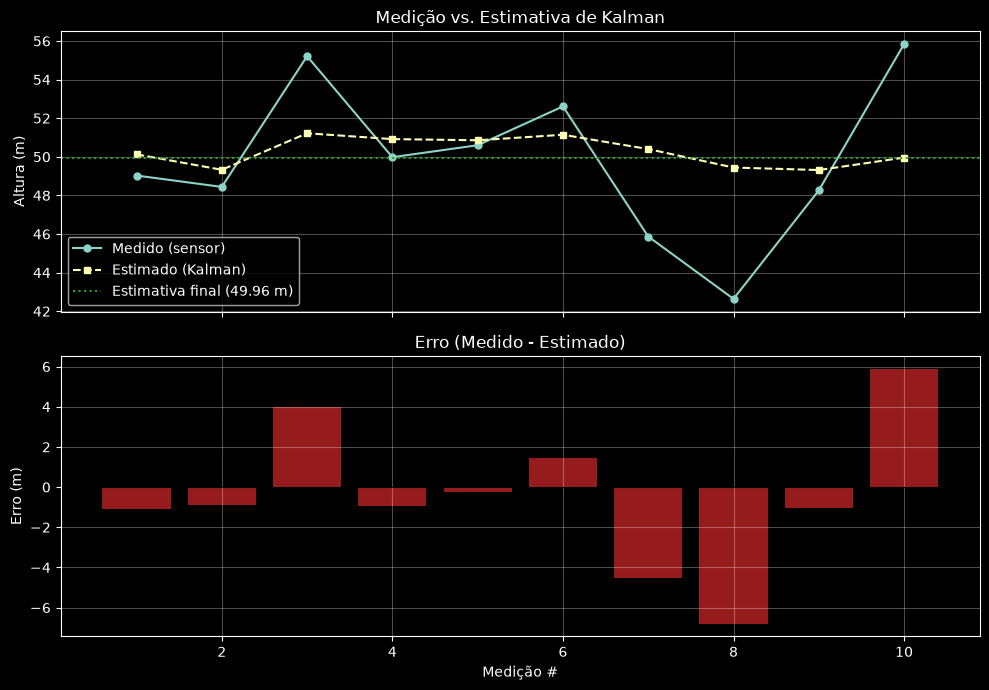

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# --- Medido vs Estimado ---
axes[0].plot(n_passos, medicoes, "o-", label="Medido (sensor)", markersize=5)
axes[0].plot(n_passos, estimativas, "s--", label="Estimado (Kalman)", markersize=5)
axes[0].axhline(y=estimativas[-1], color="tab:green", linestyle=":",
                label=f"Estimativa final ({estimativas[-1]:.2f} m)")
axes[0].set_ylabel("Altura (m)")
axes[0].set_title("Medição vs. Estimativa de Kalman")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Erro ---
axes[1].bar(n_passos, erros, color="tab:red", alpha=0.7)
axes[1].axhline(y=0, color="black", linewidth=0.8)
axes[1].set_xlabel("Medição #")
axes[1].set_ylabel("Erro (m)")
axes[1].set_title("Erro (Medido - Estimado)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

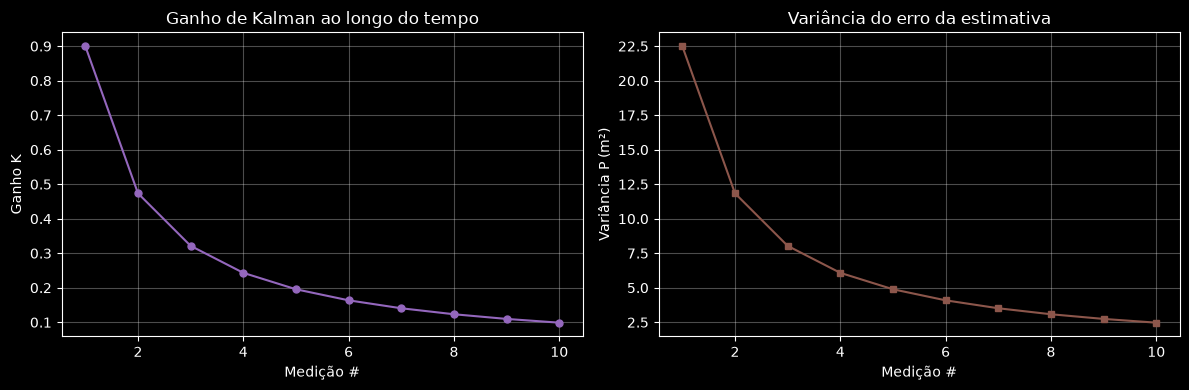

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Ganho de Kalman ---
axes[0].plot(n_passos, ganhos, "o-", color="tab:purple", markersize=5)
axes[0].set_xlabel("Medição #")
axes[0].set_ylabel("Ganho K")
axes[0].set_title("Ganho de Kalman ao longo do tempo")
axes[0].grid(True, alpha=0.3)

# --- Variância do erro ---
axes[1].plot(n_passos, variancias, "s-", color="tab:brown", markersize=5)
axes[1].set_xlabel("Medição #")
axes[1].set_ylabel("Variância P (m²)")
axes[1].set_title("Variância do erro da estimativa")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()